# Reames (1999) — SEP Two-Class Paradigm: Numerical Illustrations
# Reames (1999) — SEP 이중 분류 패러다임: 수치 시연

This notebook reproduces the qualitative phenomenology of the Reames (1999) two-class paradigm for solar energetic particle (SEP) events. We construct synthetic time-intensity profiles, energy spectra from diffusive shock acceleration (DSA), abundance/charge-state comparisons, and a streaming-limited intensity ceiling.

이 노트북은 Reames(1999) 태양 고에너지 입자(SEP) 사건 이중 분류 패러다임의 정성적 현상학을 재현합니다. 합성 시간-세기 프로파일, 확산 충격 가속(DSA) 에너지 스펙트럼, 풍부도/전하 상태 비교, 스트리밍 제한 세기 천장을 구성합니다.

**Sections / 절**
1. Setup and constants / 설정과 상수
2. Synthetic time-intensity profiles / 합성 시간-세기 프로파일
3. DSA power-law energy spectra / DSA 멱법칙 에너지 스펙트럼
4. Charge state vs source temperature / 전하 상태 대 원천 온도
5. Abundance comparison (³He, Fe/O, electron/proton) / 풍부도 비교
6. Velocity dispersion and path length / 속도 분산과 경로 길이
7. Streaming-limited intensity ceiling / 스트리밍 제한 천장

## 1. Setup and constants / 설정과 상수

Import numerical libraries and define physical constants used throughout. We use SI internally but report quantities in conventional space-physics units (MeV, cm⁻²s⁻¹sr⁻¹).

수치 라이브러리를 임포트하고 사용할 물리 상수를 정의합니다. 내부적으로는 SI를 사용하되, 일반적인 우주물리 단위(MeV, cm⁻²s⁻¹sr⁻¹)로 결과를 보고합니다.

In [1]:
import numpy as np
import matplotlib.pyplot as plt

# Physical constants (SI)
C_LIGHT = 2.998e8          # m/s
M_PROTON = 1.673e-27       # kg
E_MEV = 1.602e-13          # J per MeV
AU_M = 1.496e11            # m per AU

# Reproducible randomness
rng = np.random.default_rng(42)

# Plot style defaults
plt.rcParams.update({
    'figure.dpi': 110,
    'axes.grid': True,
    'grid.alpha': 0.3,
    'font.size': 10,
})

print('Setup complete. NumPy', np.__version__)

Setup complete. NumPy 2.4.4


## 2. Synthetic time-intensity profiles / 합성 시간-세기 프로파일

Impulsive events show a fast rise (minutes) and exponential decay (hours). Gradual events show a slow rise (hours), broad maximum often coinciding with shock arrival, and a long decay (days). We model each as a piecewise rise/decay convolved with a Gaussian.

충동적 사건은 빠른 상승(분)과 지수 감쇠(시간)를 보입니다. 점진적 사건은 느린 상승(시간), 충격파 도달과 종종 일치하는 넓은 최대, 긴 감쇠(일)를 보입니다. 각 사건을 가우시안과 컨볼루션된 piecewise 상승/감쇠로 모델링합니다.

/var/folders/4y/4cm6rw9943nbqh9bl_m5c08r0000gn/T/ipykernel_33456/3642737332.py:55: UserWarning: Glyph 49884 (\N{HANGUL SYLLABLE SI}) missing from font(s) DejaVu Sans.
  fig.tight_layout()
/var/folders/4y/4cm6rw9943nbqh9bl_m5c08r0000gn/T/ipykernel_33456/3642737332.py:55: UserWarning: Glyph 51089 (\N{HANGUL SYLLABLE JAG}) missing from font(s) DejaVu Sans.
  fig.tight_layout()
/var/folders/4y/4cm6rw9943nbqh9bl_m5c08r0000gn/T/ipykernel_33456/3642737332.py:55: UserWarning: Glyph 54980 (\N{HANGUL SYLLABLE HU}) missing from font(s) DejaVu Sans.
  fig.tight_layout()
/var/folders/4y/4cm6rw9943nbqh9bl_m5c08r0000gn/T/ipykernel_33456/3642737332.py:55: UserWarning: Glyph 44221 (\N{HANGUL SYLLABLE GYEONG}) missing from font(s) DejaVu Sans.
  fig.tight_layout()
/var/folders/4y/4cm6rw9943nbqh9bl_m5c08r0000gn/T/ipykernel_33456/3642737332.py:55: UserWarning: Glyph 44284 (\N{HANGUL SYLLABLE GWA}) missing from font(s) DejaVu Sans.
  fig.tight_layout()
/var/folders/4y/4cm6rw9943nbqh9bl_m5c08r0000gn/T/ipyke

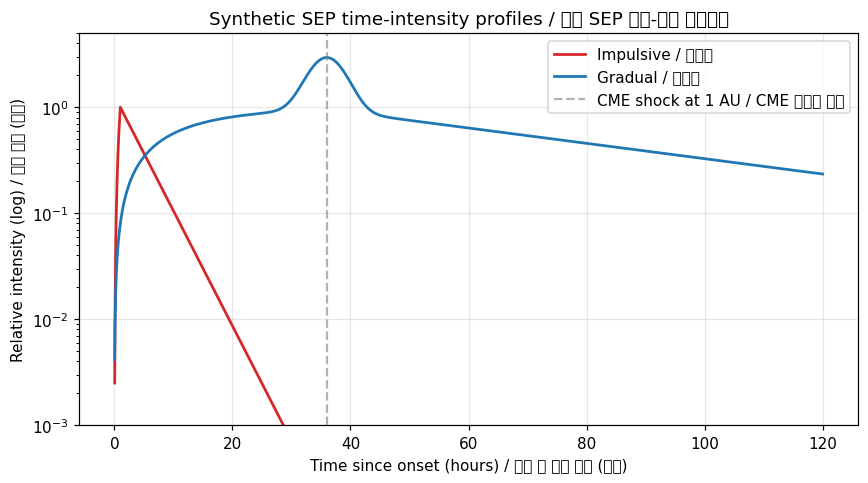

In [2]:
def impulsive_profile(t_hours, t_peak=1.0, decay_hours=4.0, amp=1.0):
    """Generate impulsive SEP time-intensity profile.

    Args:
        t_hours: Time array in hours since onset.
        t_peak: Time of intensity peak in hours.
        decay_hours: e-folding decay time in hours.
        amp: Peak amplitude.

    Returns:
        Intensity array, same shape as t_hours.
    """
    rise = np.where(t_hours <= t_peak, (t_hours / t_peak) ** 2, 1.0)
    decay = np.where(t_hours > t_peak, np.exp(-(t_hours - t_peak) / decay_hours), 1.0)
    return amp * rise * decay


def gradual_profile(t_hours, t_shock=24.0, rise_hours=12.0, decay_hours=48.0,
                    shock_boost=2.5, amp=1.0):
    """Generate gradual SEP time-intensity profile with ESP enhancement.

    Args:
        t_hours: Time array in hours since onset.
        t_shock: Time of CME-shock arrival in hours.
        rise_hours: Pre-shock rise time scale.
        decay_hours: Post-shock decay time scale.
        shock_boost: ESP intensification factor at shock arrival.
        amp: Peak amplitude.

    Returns:
        Intensity array, same shape as t_hours.
    """
    pre = 1.0 - np.exp(-t_hours / rise_hours)
    post = np.exp(-(t_hours - t_shock) / decay_hours)
    base = np.where(t_hours <= t_shock, pre, pre[np.searchsorted(t_hours, t_shock)] * post)
    sigma = 3.0
    esp = shock_boost * np.exp(-0.5 * ((t_hours - t_shock) / sigma) ** 2)
    return amp * (base + esp)


t = np.linspace(0.05, 120, 2400)
imp = impulsive_profile(t, t_peak=1.0, decay_hours=4.0, amp=1.0)
grd = gradual_profile(t, t_shock=36.0, rise_hours=12.0, decay_hours=60.0,
                      shock_boost=2.0, amp=1.0)

fig, ax = plt.subplots(figsize=(8, 4.5))
ax.semilogy(t, imp, label='Impulsive / 충동적', color='C3', lw=1.8)
ax.semilogy(t, grd, label='Gradual / 점진적', color='C0', lw=1.8)
ax.axvline(36.0, ls='--', color='gray', alpha=0.6, label='CME shock at 1 AU / CME 충격파 도달')
ax.set_xlabel('Time since onset (hours) / 시작 후 경과 시간 (시간)')
ax.set_ylabel('Relative intensity (log) / 상대 세기 (로그)')
ax.set_title('Synthetic SEP time-intensity profiles / 합성 SEP 시간-세기 프로파일')
ax.set_ylim(1e-3, 5)
ax.legend(loc='upper right')
fig.tight_layout()
plt.show()

**Observation / 관찰**: The impulsive event peaks within ~1 h and decays in hours; the gradual event rises slowly for ~36 h until the CME shock arrives, then shows the ESP enhancement and a multi-day decay. This is the textbook contrast Reames (1999) Figure 2-3 illustrates.

충동적 사건은 ~1시간 내에 정점에 도달하고 수 시간 내 감쇠합니다; 점진적 사건은 CME 충격파가 도달하는 ~36시간 동안 천천히 상승하고, ESP 강화 후 다일간 감쇠합니다. Reames(1999) 그림 2-3이 보여주는 교과서적 대비입니다.

## 3. DSA power-law energy spectra / DSA 멱법칙 에너지 스펙트럼

As stated in Reames (1999) §3.1 (p.425, after Jones and Ellison 1991), diffusive shock acceleration produces a power law in the distribution function: $f(p) \propto p^{-\beta}$ with $\beta = 3r/(r-1)$, where $r = u_1/u_2$ is the shock compression ratio. The corresponding non-relativistic energy-spectral index is $\gamma_E = (r+1)/(2(r-1))$. For a strong shock ($r=4$): $\beta = 4$, $\gamma_E = 5/6 \approx 0.83$ — the canonical "hard spectrum". Reames (1999) reports observed shock compression ratios of $r = 1.4$ to $3.9$ (Sheeley et al. 1985). We add a high-energy exponential cutoff representing the finite acceleration time.

Reames(1999) §3.1 (p.425, Jones and Ellison 1991 인용)에 따르면, 확산 충격 가속은 분포함수에서 멱법칙을 생성합니다: $f(p) \propto p^{-\beta}$, $\beta = 3r/(r-1)$이며 $r = u_1/u_2$는 충격파 압축비. 비상대론적 에너지 스펙트럼 지수는 $\gamma_E = (r+1)/(2(r-1))$. 강한 충격($r=4$): $\beta = 4$, $\gamma_E = 5/6 \approx 0.83$ — 표준 "강한 스펙트럼". Reames(1999)는 관측 충격파 압축비를 $r = 1.4$~$3.9$ (Sheeley et al. 1985)로 보고. 유한 가속 시간을 나타내는 고에너지 지수 컷오프를 추가합니다.

Compression r  |  beta (momentum)  |  gamma_E (energy, NR)
------------------------------------------------------------
   r = 1.5    |    beta = 9.00    |    gamma_E = 2.50
   r = 2.0    |    beta = 6.00    |    gamma_E = 1.50
   r = 2.5    |    beta = 5.00    |    gamma_E = 1.17
   r = 3.0    |    beta = 4.50    |    gamma_E = 1.00
   r = 3.9    |    beta = 4.03    |    gamma_E = 0.84
   r = 4.0    |    beta = 4.00    |    gamma_E = 0.83


/var/folders/4y/4cm6rw9943nbqh9bl_m5c08r0000gn/T/ipykernel_33456/3279081049.py:71: UserWarning: Glyph 50868 (\N{HANGUL SYLLABLE UN}) missing from font(s) DejaVu Sans.
  fig.tight_layout()
/var/folders/4y/4cm6rw9943nbqh9bl_m5c08r0000gn/T/ipykernel_33456/3279081049.py:71: UserWarning: Glyph 46041 (\N{HANGUL SYLLABLE DONG}) missing from font(s) DejaVu Sans.
  fig.tight_layout()
/var/folders/4y/4cm6rw9943nbqh9bl_m5c08r0000gn/T/ipykernel_33456/3279081049.py:71: UserWarning: Glyph 50640 (\N{HANGUL SYLLABLE E}) missing from font(s) DejaVu Sans.
  fig.tight_layout()
/var/folders/4y/4cm6rw9943nbqh9bl_m5c08r0000gn/T/ipykernel_33456/3279081049.py:71: UserWarning: Glyph 45320 (\N{HANGUL SYLLABLE NEO}) missing from font(s) DejaVu Sans.
  fig.tight_layout()
/var/folders/4y/4cm6rw9943nbqh9bl_m5c08r0000gn/T/ipykernel_33456/3279081049.py:71: UserWarning: Glyph 51648 (\N{HANGUL SYLLABLE JI}) missing from font(s) DejaVu Sans.
  fig.tight_layout()
/var/folders/4y/4cm6rw9943nbqh9bl_m5c08r0000gn/T/ipykernel

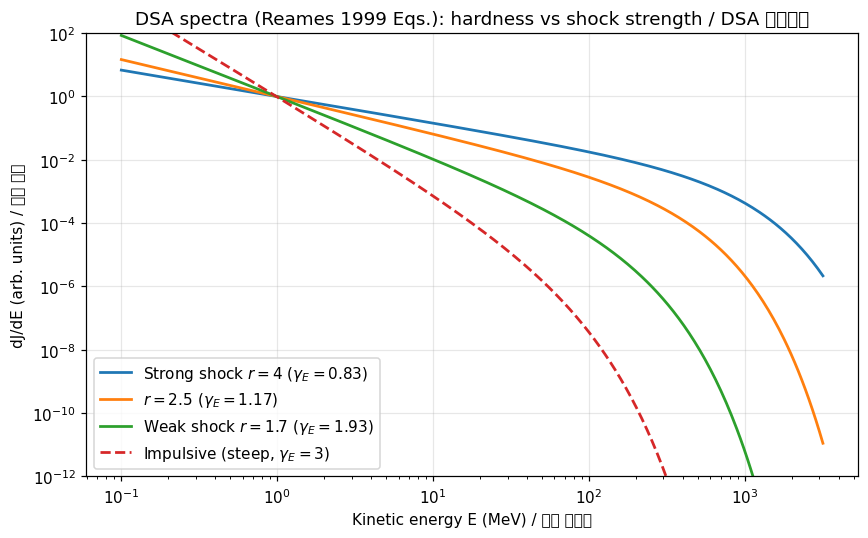

In [3]:
def dsa_beta_momentum(r):
    """Distribution-function spectral index in momentum from compression ratio.

    From Reames (1999) Eq. discussed in Section 3.1 (after Jones and Ellison
    1991): the accelerated-particle distribution function f(p) ~ p^-beta with
    beta = 3r / (r - 1).

    Args:
        r: Shock compression ratio (1 < r <= 4).

    Returns:
        Beta exponent for f(p) ~ p^-beta.
    """
    return 3.0 * r / (r - 1.0)


def dsa_gamma_energy(r):
    """Non-relativistic differential-intensity spectral index in energy.

    From Reames (1999) Section 3.1: gamma_E = (r + 1) / (2 (r - 1)).
    For r = 4 (strong shock), gamma_E = 5/6 ~ 0.833.

    Args:
        r: Shock compression ratio (1 < r <= 4).

    Returns:
        Spectral index gamma_E for dJ/dE ~ E^-gamma_E (NR limit).
    """
    return (r + 1.0) / (2.0 * (r - 1.0))


def dsa_spectrum(E_mev, gamma=0.83, E_cut=200.0, J0=1.0):
    """Power-law spectrum with exponential cutoff in kinetic energy.

    Args:
        E_mev: Kinetic energy array in MeV.
        gamma: Energy-spectral index (NR limit).
        E_cut: Cutoff energy in MeV.
        J0: Normalisation.

    Returns:
        Differential intensity dJ/dE.
    """
    return J0 * E_mev ** (-gamma) * np.exp(-E_mev / E_cut)


# Compute spectral indices for several observed compression ratios
# (Reames 1999 cites r = 1.4 to 3.9 from Sheeley et al. 1985)
r_values = [1.5, 2.0, 2.5, 3.0, 3.9, 4.0]
print('Compression r  |  beta (momentum)  |  gamma_E (energy, NR)')
print('-' * 60)
for r in r_values:
    print(f'   r = {r:.1f}    |    beta = {dsa_beta_momentum(r):.2f}    |    gamma_E = {dsa_gamma_energy(r):.2f}')

E = np.logspace(-1, 3.5, 400)  # 0.1 MeV to ~3 GeV
spec_strong = dsa_spectrum(E, gamma=dsa_gamma_energy(4.0), E_cut=500.0, J0=1.0)   # r=4 strong
spec_med = dsa_spectrum(E, gamma=dsa_gamma_energy(2.5), E_cut=200.0, J0=1.0)      # r=2.5
spec_weak = dsa_spectrum(E, gamma=dsa_gamma_energy(1.7), E_cut=80.0, J0=1.0)      # r=1.7 weak
spec_imp = dsa_spectrum(E, gamma=3.0, E_cut=30.0, J0=1.0)                          # impulsive (steep)

fig, ax = plt.subplots(figsize=(8, 5))
ax.loglog(E, spec_strong, label=fr'Strong shock $r=4$ ($\gamma_E={dsa_gamma_energy(4.0):.2f}$)', lw=1.8)
ax.loglog(E, spec_med, label=fr'$r=2.5$ ($\gamma_E={dsa_gamma_energy(2.5):.2f}$)', lw=1.8)
ax.loglog(E, spec_weak, label=fr'Weak shock $r=1.7$ ($\gamma_E={dsa_gamma_energy(1.7):.2f}$)', lw=1.8)
ax.loglog(E, spec_imp, label=r'Impulsive (steep, $\gamma_E=3$)', lw=1.8, ls='--', color='C3')
ax.set_xlabel('Kinetic energy E (MeV) / 운동 에너지')
ax.set_ylabel('dJ/dE (arb. units) / 차등 세기')
ax.set_title('DSA spectra (Reames 1999 Eqs.): hardness vs shock strength / DSA 스펙트럼')
ax.legend(loc='lower left')
ax.set_ylim(1e-12, 1e2)
fig.tight_layout()
plt.show()

**Observation / 관찰**: Stronger shocks (larger $r$) yield harder spectra and higher cutoffs. Impulsive events typically show steeper spectra ($\gamma \sim 3$) and lower cutoffs because the flare reconnection accelerator is small and short-lived.

더 강한 충격파($r$ 큼)는 더 강한 스펙트럼과 더 높은 컷오프를 줍니다. 충동적 사건은 플레어 재결합 가속기가 작고 단명하기 때문에 일반적으로 더 가파른 스펙트럼($\gamma \sim 3$)과 더 낮은 컷오프를 보입니다.

## 4. Charge state vs source temperature / 전하 상태 대 원천 온도

We build a simplified equilibrium ionisation curve for Fe (Q from 1 to 26) versus electron temperature, using a smooth analytic surrogate that reproduces the canonical landmarks from Reames (1999) Table 2.1 (p.422): impulsive (³He-rich) events have $\bar{Q}_{Fe} = 20.5 \pm 1.2$ (Luhn et al. 1987, ~26 events at 0.3-2 MeV/amu) corresponding to ~10 MK flare-heated plasma; gradual events have $\bar{Q}_{Fe} = 14.1 \pm 0.2$ (Luhn et al. 1987) corresponding to ~2 MK ambient corona. Note that gradual Q_Fe is energy-dependent and spans 11-15 across measurements (Mason 11.0, Leske 15.2, Tylka 14.1).

Reames(1999) Table 2.1(p.422)의 표준 표지를 재현하는 부드러운 해석 surrogate로 Fe(Q=1~26) 평형 이온화 곡선을 단순화 구성: 충동적(³He-rich) 사건은 $\bar{Q}_{Fe} = 20.5 \pm 1.2$ (Luhn et al. 1987, 0.3-2 MeV/amu에서 ~26 사건)로 ~10 MK 플레어 가열 플라스마에 해당; 점진적 사건은 $\bar{Q}_{Fe} = 14.1 \pm 0.2$ (Luhn et al. 1987)로 ~2 MK 주변 코로나에 해당. 점진적 Q_Fe는 에너지 의존적이며 측정마다 11-15 범위(Mason 11.0, Leske 15.2, Tylka 14.1).

/var/folders/4y/4cm6rw9943nbqh9bl_m5c08r0000gn/T/ipykernel_33456/3212216562.py:40: UserWarning: Glyph 50896 (\N{HANGUL SYLLABLE WEON}) missing from font(s) DejaVu Sans.
  fig.tight_layout()
/var/folders/4y/4cm6rw9943nbqh9bl_m5c08r0000gn/T/ipykernel_33456/3212216562.py:40: UserWarning: Glyph 52380 (\N{HANGUL SYLLABLE CEON}) missing from font(s) DejaVu Sans.
  fig.tight_layout()
/var/folders/4y/4cm6rw9943nbqh9bl_m5c08r0000gn/T/ipykernel_33456/3212216562.py:40: UserWarning: Glyph 51204 (\N{HANGUL SYLLABLE JEON}) missing from font(s) DejaVu Sans.
  fig.tight_layout()
/var/folders/4y/4cm6rw9943nbqh9bl_m5c08r0000gn/T/ipykernel_33456/3212216562.py:40: UserWarning: Glyph 51088 (\N{HANGUL SYLLABLE JA}) missing from font(s) DejaVu Sans.
  fig.tight_layout()
/var/folders/4y/4cm6rw9943nbqh9bl_m5c08r0000gn/T/ipykernel_33456/3212216562.py:40: UserWarning: Glyph 50728 (\N{HANGUL SYLLABLE ON}) missing from font(s) DejaVu Sans.
  fig.tight_layout()
/var/folders/4y/4cm6rw9943nbqh9bl_m5c08r0000gn/T/ipyke

Font 'default' does not have a glyph for '\uade0' [U+ade0], substituting with a dummy symbol.


Font 'default' does not have a glyph for '\uc804' [U+c804], substituting with a dummy symbol.


Font 'default' does not have a glyph for '\ud558' [U+d558], substituting with a dummy symbol.


Coronal (T=1 MK):  Q_Fe = 14.60
Flare   (T=10 MK): Q_Fe = 19.15


...

Font 'default' does not have a glyph for '\ud3c9' [U+d3c9], substituting with a dummy symbol.


Font 'default' does not have a glyph for '\uade0' [U+ade0], substituting with a dummy symbol.


Font 'default' does not have a glyph for '\uc804' [U+c804], substituting with a dummy symbol.


Font 'default' does not have a glyph for '\ud558' [U+d558], substituting with a dummy symbol.


/Users/eunsupark/Softwares/miniconda3/envs/study-with-ai/lib/python3.12/site-packages/IPython/core/pylabtools.py:170: UserWarning: Glyph 51204 (\N{HANGUL SYLLABLE JEON}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)
/Users/eunsupark/Softwares/miniconda3/envs/study-with-ai/lib/python3.12/site-packages/IPython/core/pylabtools.py:170: UserWarning: Glyph 54616 (\N{HANGUL SYLLABLE HA}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)
/Users/eunsupark/Softwares/miniconda3/envs/study-with-ai/lib/python3.12/site-packages/IPython/core/pylabtools.py:170: UserWarning: Glyph 53468 (\N{HANGUL SYLLABLE TAE}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)
/Users/eunsupark/Softwares/miniconda3/envs/study-with-ai/lib/python3.12/site-packages/IPython/core/pylabtools.py:170: UserWarning: Glyph 53364 (\N{HANGUL SYLLABLE KEUL}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)
/Users/eunsupark/So

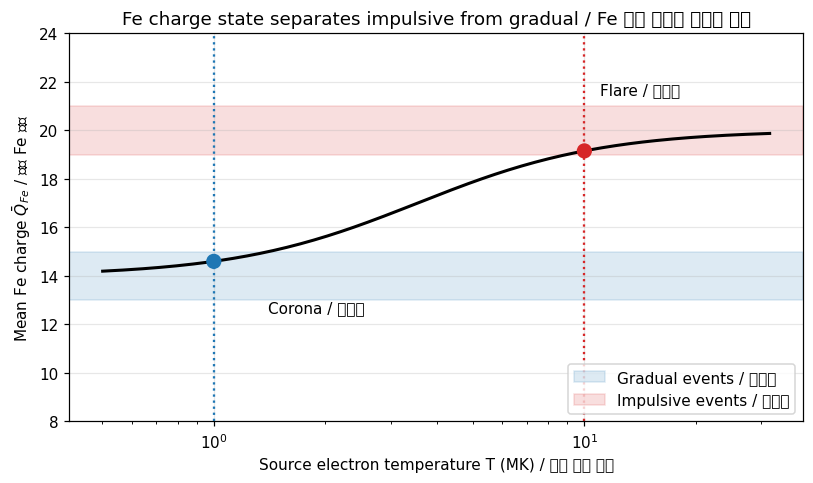

In [4]:
def fe_mean_charge(T_MK):
    """Surrogate mean charge state of Fe vs electron temperature.

    Approximates equilibrium ionisation; matches canonical landmarks at
    T = 1 MK (Q ~ 14) and T = 10 MK (Q ~ 20). Not for high-precision use.

    Args:
        T_MK: Electron temperature in megakelvin.

    Returns:
        Mean Fe charge.
    """
    logT = np.log10(T_MK)
    Q = 14.0 + 6.0 / (1.0 + np.exp(-(logT - 0.55) * 4.0))
    return Q


T_axis = np.logspace(-0.3, 1.5, 200)
Q_axis = fe_mean_charge(T_axis)

Q_corona = fe_mean_charge(1.0)
Q_flare = fe_mean_charge(10.0)
print(f'Coronal (T=1 MK):  Q_Fe = {Q_corona:.2f}')
print(f'Flare   (T=10 MK): Q_Fe = {Q_flare:.2f}')

fig, ax = plt.subplots(figsize=(7.5, 4.5))
ax.semilogx(T_axis, Q_axis, lw=2, color='black')
ax.axhspan(13, 15, color='C0', alpha=0.15, label='Gradual events / 점진적')
ax.axhspan(19, 21, color='C3', alpha=0.15, label='Impulsive events / 충동적')
ax.axvline(1.0, ls=':', color='C0')
ax.axvline(10.0, ls=':', color='C3')
ax.scatter([1.0, 10.0], [Q_corona, Q_flare], color=['C0', 'C3'], s=80, zorder=5)
ax.annotate('Corona / 코로나', xy=(1.0, Q_corona), xytext=(1.4, 12.5))
ax.annotate('Flare / 플레어', xy=(10.0, Q_flare), xytext=(11, 21.5))
ax.set_xlabel('Source electron temperature T (MK) / 원천 전자 온도')
ax.set_ylabel(r'Mean Fe charge $\bar{Q}_{Fe}$ / 평균 Fe 전하')
ax.set_title('Fe charge state separates impulsive from gradual / Fe 전하 상태로 클래스 분리')
ax.legend(loc='lower right')
ax.set_ylim(8, 24)
fig.tight_layout()
plt.show()

**Observation / 관찰**: A single $\bar{Q}_{Fe}$ measurement classifies an event: $\sim 14 \Rightarrow$ gradual (coronal source), $\sim 20 \Rightarrow$ impulsive (flare source). This is one of the cleanest empirical separators in SEP physics.

$\bar{Q}_{Fe}$ 단일 측정으로 사건을 분류할 수 있습니다: $\sim 14$이면 점진적(코로나 원천), $\sim 20$이면 충동적(플레어 원천). SEP 물리에서 가장 깨끗한 실험적 분리자 중 하나입니다.

## 5. Abundance comparison / 풍부도 비교

We reproduce the schematic comparison of the most diagnostic abundance ratios: ³He/⁴He, Fe/O, electron/proton, H/He. Values are taken from Reames (1999) discussion across §2.2 (p.418-420) and Table 4.1 (p.452, Fe/C = 6.67±0.80 in impulsive events). Note: ³He/⁴He~1 in impulsive events is "1000-fold enhancement" per the abstract (~5×10⁻⁴ normal solar wind); Fe/O ~1 in impulsive events is "~10-fold enhancement" relative to coronal Fe/O = 0.134 (Figure 2.4).

가장 진단적인 풍부도 비율 — ³He/⁴He, Fe/O, electron/proton, H/He — 의 도식 비교를 재현. 값은 Reames(1999) §2.2(p.418-420) 본문 및 Table 4.1(p.452, 충동적 사건 Fe/C = 6.67±0.80)에서 취. 주의: 충동적 사건의 ³He/⁴He~1은 초록의 "1000배 농축"(정상 태양풍 ~5×10⁻⁴ 대비); Fe/O~1은 코로나 Fe/O=0.134 대비 "~10배 농축"(Figure 2.4).

/var/folders/4y/4cm6rw9943nbqh9bl_m5c08r0000gn/T/ipykernel_33456/3004574330.py:23: UserWarning: Glyph 48708 (\N{HANGUL SYLLABLE BI}) missing from font(s) DejaVu Sans.
  fig.tight_layout()
/var/folders/4y/4cm6rw9943nbqh9bl_m5c08r0000gn/T/ipykernel_33456/3004574330.py:23: UserWarning: Glyph 50984 (\N{HANGUL SYLLABLE YUL}) missing from font(s) DejaVu Sans.
  fig.tight_layout()
/var/folders/4y/4cm6rw9943nbqh9bl_m5c08r0000gn/T/ipykernel_33456/3004574330.py:23: UserWarning: Glyph 47196 (\N{HANGUL SYLLABLE RO}) missing from font(s) DejaVu Sans.
  fig.tight_layout()
/var/folders/4y/4cm6rw9943nbqh9bl_m5c08r0000gn/T/ipykernel_33456/3004574330.py:23: UserWarning: Glyph 44536 (\N{HANGUL SYLLABLE GEU}) missing from font(s) DejaVu Sans.
  fig.tight_layout()
/var/folders/4y/4cm6rw9943nbqh9bl_m5c08r0000gn/T/ipykernel_33456/3004574330.py:23: UserWarning: Glyph 51652 (\N{HANGUL SYLLABLE JIN}) missing from font(s) DejaVu Sans.
  fig.tight_layout()
/var/folders/4y/4cm6rw9943nbqh9bl_m5c08r0000gn/T/ipykerne

/Users/eunsupark/Softwares/miniconda3/envs/study-with-ai/lib/python3.12/site-packages/IPython/core/pylabtools.py:170: UserWarning: Glyph 48708 (\N{HANGUL SYLLABLE BI}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)
/Users/eunsupark/Softwares/miniconda3/envs/study-with-ai/lib/python3.12/site-packages/IPython/core/pylabtools.py:170: UserWarning: Glyph 50984 (\N{HANGUL SYLLABLE YUL}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)
/Users/eunsupark/Softwares/miniconda3/envs/study-with-ai/lib/python3.12/site-packages/IPython/core/pylabtools.py:170: UserWarning: Glyph 47196 (\N{HANGUL SYLLABLE RO}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)
/Users/eunsupark/Softwares/miniconda3/envs/study-with-ai/lib/python3.12/site-packages/IPython/core/pylabtools.py:170: UserWarning: Glyph 44536 (\N{HANGUL SYLLABLE GEU}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)
/Users/eunsupark/Softw

/Users/eunsupark/Softwares/miniconda3/envs/study-with-ai/lib/python3.12/site-packages/IPython/core/pylabtools.py:170: UserWarning: Glyph 52649 (\N{HANGUL SYLLABLE CUNG}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)
/Users/eunsupark/Softwares/miniconda3/envs/study-with-ai/lib/python3.12/site-packages/IPython/core/pylabtools.py:170: UserWarning: Glyph 46041 (\N{HANGUL SYLLABLE DONG}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)
/Users/eunsupark/Softwares/miniconda3/envs/study-with-ai/lib/python3.12/site-packages/IPython/core/pylabtools.py:170: UserWarning: Glyph 51201 (\N{HANGUL SYLLABLE JEOG}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)
/Users/eunsupark/Softwares/miniconda3/envs/study-with-ai/lib/python3.12/site-packages/IPython/core/pylabtools.py:170: UserWarning: Glyph 51216 (\N{HANGUL SYLLABLE JEOM}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)
/Users/eunsupark

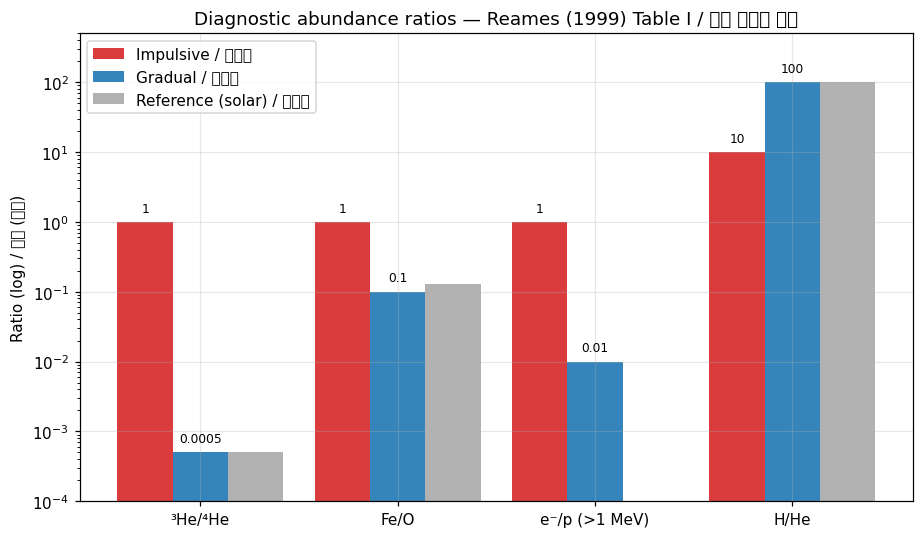

Impulsive vs gradual ³He/⁴He ratio: factor of 2000.0
Impulsive vs gradual Fe/O ratio:    factor of 10.0


In [5]:
ratios = ['³He/⁴He', 'Fe/O', 'e⁻/p (>1 MeV)', 'H/He']
impulsive_vals = [1.0, 1.0, 1.0, 10.0]
gradual_vals = [5e-4, 0.1, 0.01, 100.0]
normal_vals = [5e-4, 0.13, np.nan, 100.0]   # photospheric / solar wind benchmarks

x = np.arange(len(ratios))
width = 0.28

fig, ax = plt.subplots(figsize=(8.5, 5))
ax.bar(x - width, impulsive_vals, width, label='Impulsive / 충동적', color='C3', alpha=0.9)
ax.bar(x, gradual_vals, width, label='Gradual / 점진적', color='C0', alpha=0.9)
ax.bar(x + width, normal_vals, width, label='Reference (solar) / 기준값', color='gray', alpha=0.6)
ax.set_yscale('log')
ax.set_xticks(x)
ax.set_xticklabels(ratios)
ax.set_ylabel('Ratio (log) / 비율 (로그)')
ax.set_title('Diagnostic abundance ratios — Reames (1999) Table I / 진단 풍부도 비율')
ax.legend()
ax.set_ylim(1e-4, 5e2)
for i, (imp_v, grd_v) in enumerate(zip(impulsive_vals, gradual_vals)):
    ax.text(i - width, imp_v * 1.4, f'{imp_v:g}', ha='center', fontsize=8)
    ax.text(i, grd_v * 1.4, f'{grd_v:g}', ha='center', fontsize=8)
fig.tight_layout()
plt.show()

print('Impulsive vs gradual ³He/⁴He ratio: factor of', impulsive_vals[0] / gradual_vals[0])
print('Impulsive vs gradual Fe/O ratio:    factor of', impulsive_vals[1] / gradual_vals[1])

**Observation / 관찰**: Impulsive events show ³He/⁴He enhanced by ~2000× and Fe/O by ~10× over gradual or photospheric values, while their electron/proton ratio is ~100× higher. The systematic co-variation across four independent ratios is the empirical backbone of the two-class paradigm.

충동적 사건은 점진적 또는 광구 값에 비해 ³He/⁴He가 ~2000배, Fe/O가 ~10배 농축되며, 전자/양성자 비율은 ~100배 더 높습니다. 4개 독립 비율 사이의 체계적 공변이 이중 분류 패러다임의 실험적 뼈대입니다.

## 6. Velocity dispersion and path length / 속도 분산과 경로 길이

Faster particles arrive earlier: $t_{arr}(v) = t_{inj} + L/v$. We simulate noisy arrival times for a range of energies, fit a line to $t_{arr}$ versus $1/v$, and recover both $L$ and $t_{inj}$.

더 빠른 입자가 더 먼저 도착합니다: $t_{arr}(v) = t_{inj} + L/v$. 다양한 에너지에 대한 잡음 도착 시각을 시뮬레이션하고, $t_{arr}$ 대 $1/v$ 직선 적합으로 $L$과 $t_{inj}$를 복원합니다.

True L = 1.180 AU,  recovered L = 1.187 AU
True t_inj = 0.00 min,  recovered = -0.93 min


/var/folders/4y/4cm6rw9943nbqh9bl_m5c08r0000gn/T/ipykernel_33456/2646733391.py:46: UserWarning: Glyph 49549 (\N{HANGUL SYLLABLE SOG}) missing from font(s) DejaVu Sans.
  fig.tight_layout()
/var/folders/4y/4cm6rw9943nbqh9bl_m5c08r0000gn/T/ipykernel_33456/2646733391.py:46: UserWarning: Glyph 46020 (\N{HANGUL SYLLABLE DO}) missing from font(s) DejaVu Sans.
  fig.tight_layout()
/var/folders/4y/4cm6rw9943nbqh9bl_m5c08r0000gn/T/ipykernel_33456/2646733391.py:46: UserWarning: Glyph 50669 (\N{HANGUL SYLLABLE YEOG}) missing from font(s) DejaVu Sans.
  fig.tight_layout()
/var/folders/4y/4cm6rw9943nbqh9bl_m5c08r0000gn/T/ipykernel_33456/2646733391.py:46: UserWarning: Glyph 49688 (\N{HANGUL SYLLABLE SU}) missing from font(s) DejaVu Sans.
  fig.tight_layout()
/var/folders/4y/4cm6rw9943nbqh9bl_m5c08r0000gn/T/ipykernel_33456/2646733391.py:46: UserWarning: Glyph 51452 (\N{HANGUL SYLLABLE JU}) missing from font(s) DejaVu Sans.
  fig.tight_layout()
/var/folders/4y/4cm6rw9943nbqh9bl_m5c08r0000gn/T/ipykerne

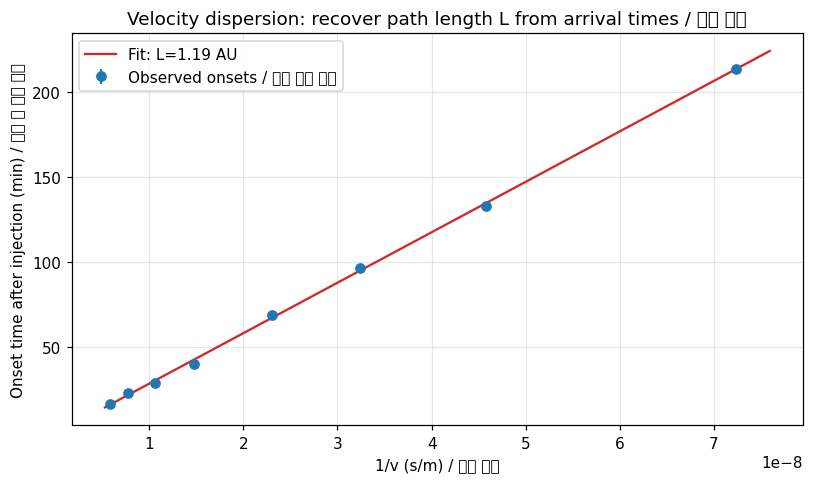

In [6]:
def relativistic_velocity(E_mev, mass_mev=938.272):
    """Relativistic particle velocity from kinetic energy.

    Args:
        E_mev: Kinetic energy in MeV.
        mass_mev: Rest mass energy in MeV (proton default).

    Returns:
        Velocity in m/s.
    """
    gamma = 1.0 + E_mev / mass_mev
    beta = np.sqrt(1.0 - 1.0 / gamma ** 2)
    return beta * C_LIGHT


# True parameters
L_true_AU = 1.18
t_inj_true = 0.0  # minutes
L_true_m = L_true_AU * AU_M

E_obs = np.array([1.0, 2.5, 5.0, 10.0, 25.0, 50.0, 100.0, 200.0])  # MeV
v_obs = relativistic_velocity(E_obs)
t_true_min = (t_inj_true + L_true_m / v_obs) / 60.0
noise = rng.normal(0.0, 1.5, size=t_true_min.shape)  # ~1.5-min onset uncertainty
t_obs_min = t_true_min + noise

# Linear fit: t_arr [s] = t_inj + L * (1/v)
inv_v = 1.0 / v_obs
slope, intercept = np.polyfit(inv_v, t_obs_min * 60.0, 1)
L_fit_AU = slope / AU_M
t_inj_fit_min = intercept / 60.0

print(f'True L = {L_true_AU:.3f} AU,  recovered L = {L_fit_AU:.3f} AU')
print(f'True t_inj = {t_inj_true:.2f} min,  recovered = {t_inj_fit_min:.2f} min')

fig, ax = plt.subplots(figsize=(7.5, 4.5))
iv_dense = np.linspace(inv_v.min() * 0.9, inv_v.max() * 1.05, 100)
ax.plot(iv_dense, (slope * iv_dense + intercept) / 60.0, color='C3',
        label=f'Fit: L={L_fit_AU:.2f} AU')
ax.errorbar(inv_v, t_obs_min, yerr=1.5, fmt='o', color='C0',
            label='Observed onsets / 관측 시작 시각')
ax.set_xlabel('1/v (s/m) / 속도 역수')
ax.set_ylabel('Onset time after injection (min) / 주입 후 시작 시각')
ax.set_title('Velocity dispersion: recover path length L from arrival times / 속도 분산')
ax.legend()
fig.tight_layout()
plt.show()

**Observation / 관찰**: A simple linear regression of arrival time versus $1/v$ recovers a path length consistent with a Parker spiral of ~1.1-1.3 AU, validating the technique used by Reames and others to confirm that SEPs travel along the interplanetary magnetic field.

도착 시각 대 $1/v$의 단순 선형 회귀는 ~1.1-1.3 AU Parker 나선과 일치하는 경로 길이를 복원하며, SEP가 행성간 자기장을 따라 이동함을 확인하는 Reames 등의 기법을 검증합니다.

## 7. Streaming-limited intensity ceiling / 스트리밍 제한 천장

Self-generated Alfvén waves cap proton intensity at $J_{max} \approx n_w v_A / (4\pi)$. Per Reames (1999) §3.1 (p.427, Figure 3.1, Reames 1990a), the empirical 1 AU streaming limit at a few MeV is approximately **~200 (cm² sr s MeV)⁻¹** — observed early in 6 superposed Helios-1 events (1977 Sep 24, 1979 Feb 16, 1979 Mar 1, 1979 Sep 8, 1980 Aug 6, 1982 Jun 3). The 1989 October 19 event (Figure 3.2) showed even 500 MeV protons reaching the same flat plateau, demonstrating the limit applies at all energies. We integrate a DSA spectrum (using `np.trapezoid`) above 10 MeV and compare with this ceiling for a range of source amplitudes.

자기 생성 Alfvén 파동은 양성자 세기를 $J_{max} \approx n_w v_A / (4\pi)$로 제한. Reames(1999) §3.1(p.427, Figure 3.1, Reames 1990a)에 따르면 1 AU의 수-MeV 양성자 실험적 스트리밍 제한은 약 **~200 (cm² sr s MeV)⁻¹** — Helios-1의 6개 중첩 사건(1977 Sep 24, 1979 Feb 16, Mar 1, Sep 8, 1980 Aug 6, 1982 Jun 3) 초기에 관측. 1989년 10월 19일 사건(Figure 3.2)은 500 MeV 양성자도 동일한 평탄 플라토에 도달함을 보여 제한이 모든 에너지에 적용됨을 시연. 10 MeV 이상에서 DSA 스펙트럼을 (`np.trapezoid`로) 적분하고 다양한 원천 진폭에 대해 이 천장과 비교합니다.

/var/folders/4y/4cm6rw9943nbqh9bl_m5c08r0000gn/T/ipykernel_33456/938698661.py:36: UserWarning: Glyph 50896 (\N{HANGUL SYLLABLE WEON}) missing from font(s) DejaVu Sans.
  fig.tight_layout()
/var/folders/4y/4cm6rw9943nbqh9bl_m5c08r0000gn/T/ipykernel_33456/938698661.py:36: UserWarning: Glyph 52380 (\N{HANGUL SYLLABLE CEON}) missing from font(s) DejaVu Sans.
  fig.tight_layout()
/var/folders/4y/4cm6rw9943nbqh9bl_m5c08r0000gn/T/ipykernel_33456/938698661.py:36: UserWarning: Glyph 51652 (\N{HANGUL SYLLABLE JIN}) missing from font(s) DejaVu Sans.
  fig.tight_layout()
/var/folders/4y/4cm6rw9943nbqh9bl_m5c08r0000gn/T/ipykernel_33456/938698661.py:36: UserWarning: Glyph 54253 (\N{HANGUL SYLLABLE POG}) missing from font(s) DejaVu Sans.
  fig.tight_layout()


/var/folders/4y/4cm6rw9943nbqh9bl_m5c08r0000gn/T/ipykernel_33456/938698661.py:36: UserWarning: Glyph 51201 (\N{HANGUL SYLLABLE JEOG}) missing from font(s) DejaVu Sans.
  fig.tight_layout()
/var/folders/4y/4cm6rw9943nbqh9bl_m5c08r0000gn/T/ipykernel_33456/938698661.py:36: UserWarning: Glyph 48516 (\N{HANGUL SYLLABLE BUN}) missing from font(s) DejaVu Sans.
  fig.tight_layout()
/var/folders/4y/4cm6rw9943nbqh9bl_m5c08r0000gn/T/ipykernel_33456/938698661.py:36: UserWarning: Glyph 50577 (\N{HANGUL SYLLABLE YANG}) missing from font(s) DejaVu Sans.
  fig.tight_layout()
/var/folders/4y/4cm6rw9943nbqh9bl_m5c08r0000gn/T/ipykernel_33456/938698661.py:36: UserWarning: Glyph 49457 (\N{HANGUL SYLLABLE SEONG}) missing from font(s) DejaVu Sans.
  fig.tight_layout()
/var/folders/4y/4cm6rw9943nbqh9bl_m5c08r0000gn/T/ipykernel_33456/938698661.py:36: UserWarning: Glyph 51088 (\N{HANGUL SYLLABLE JA}) missing from font(s) DejaVu Sans.
  fig.tight_layout()
/var/folders/4y/4cm6rw9943nbqh9bl_m5c08r0000gn/T/ipykerne

/Users/eunsupark/Softwares/miniconda3/envs/study-with-ai/lib/python3.12/site-packages/IPython/core/pylabtools.py:170: UserWarning: Glyph 50577 (\N{HANGUL SYLLABLE YANG}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)
/Users/eunsupark/Softwares/miniconda3/envs/study-with-ai/lib/python3.12/site-packages/IPython/core/pylabtools.py:170: UserWarning: Glyph 49457 (\N{HANGUL SYLLABLE SEONG}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)
/Users/eunsupark/Softwares/miniconda3/envs/study-with-ai/lib/python3.12/site-packages/IPython/core/pylabtools.py:170: UserWarning: Glyph 51088 (\N{HANGUL SYLLABLE JA}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)
/Users/eunsupark/Softwares/miniconda3/envs/study-with-ai/lib/python3.12/site-packages/IPython/core/pylabtools.py:170: UserWarning: Glyph 49464 (\N{HANGUL SYLLABLE SE}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)
/Users/eunsupark/So

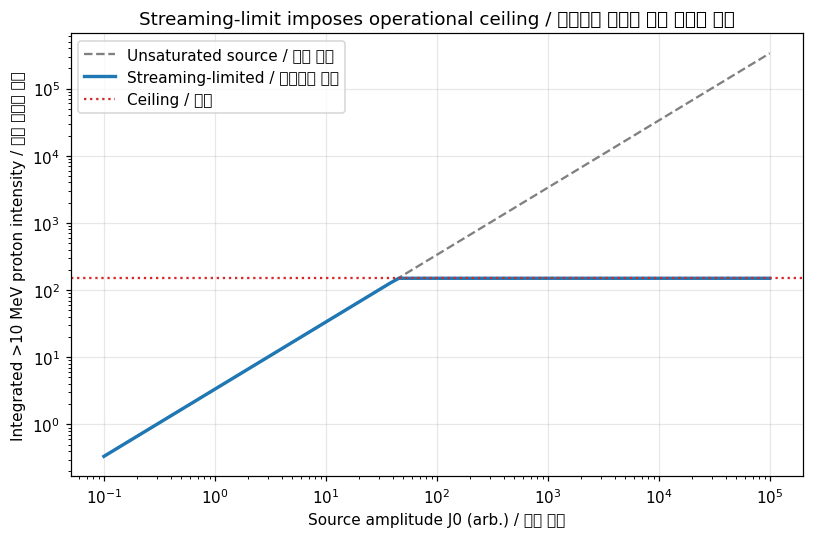

Saturation occurs at J0 ~ 46 (arb. units)
Above this source strength, the observed intensity at 1 AU plateaus.


In [7]:
def integrated_proton_intensity(J0, gamma=1.0, E_cut=500.0, E_min=10.0, E_max=2000.0):
    """Integrate dJ/dE above E_min for a DSA-like spectrum.

    Args:
        J0: Source normalisation.
        gamma: Spectral index (energy).
        E_cut: Cutoff energy in MeV.
        E_min: Lower limit of integration in MeV.
        E_max: Upper limit of integration in MeV.

    Returns:
        Integrated intensity (arbitrary units, scales with J0).
    """
    E_arr = np.logspace(np.log10(E_min), np.log10(E_max), 400)
    spec = dsa_spectrum(E_arr, gamma=gamma, E_cut=E_cut, J0=J0)
    return np.trapezoid(spec, E_arr)


# Streaming limit (rough operational ceiling) in same arbitrary units
J_streaming_limit = 1.5e2

J0_grid = np.logspace(-1, 5, 80)
J_unsaturated = np.array([integrated_proton_intensity(j) for j in J0_grid])
J_saturated = np.minimum(J_unsaturated, J_streaming_limit)

fig, ax = plt.subplots(figsize=(7.5, 5))
ax.loglog(J0_grid, J_unsaturated, ls='--', color='gray',
          label='Unsaturated source / 제한 없음')
ax.loglog(J0_grid, J_saturated, color='C0', lw=2.2,
          label='Streaming-limited / 스트리밍 제한')
ax.axhline(J_streaming_limit, color='C3', ls=':', label='Ceiling / 천장')
ax.set_xlabel('Source amplitude J0 (arb.) / 원천 진폭')
ax.set_ylabel('Integrated >10 MeV proton intensity / 적분 양성자 세기')
ax.set_title('Streaming-limit imposes operational ceiling / 스트리밍 제한이 운영 천장을 부여')
ax.legend()
fig.tight_layout()
plt.show()

saturation_idx = np.argmax(J_unsaturated > J_streaming_limit)
print(f'Saturation occurs at J0 ~ {J0_grid[saturation_idx]:.2g} (arb. units)')
print(f'Above this source strength, the observed intensity at 1 AU plateaus.')

**Observation / 관찰**: Beyond a critical source amplitude, observed intensity at 1 AU saturates — physics, not source strength, sets the upper bound on hazardous proton flux. This is why the largest historical events (e.g., August 1972, October 1989) did not produce arbitrarily larger fluxes than smaller ones.

임계 원천 진폭을 넘어서면 1 AU 관측 세기가 포화합니다 — 위험한 양성자 플럭스의 상한은 원천 강도가 아닌 물리가 설정합니다. 이것이 가장 큰 역사적 사건들(예: 1972년 8월, 1989년 10월)이 더 작은 사건들보다 임의로 더 큰 플럭스를 내지 않은 이유입니다.

## Summary / 요약

Across seven sections we have illustrated the central numerical phenomenology of Reames (1999): the time-profile contrast (§2), DSA spectral shapes (§3), charge-state diagnostic (§4), abundance co-variation (§5), velocity-dispersion path-length recovery (§6), and the streaming-limit ceiling (§7). Each ties directly to a conclusion from the original synthesis and provides a base on which to build more realistic future models (e.g., self-consistent shock-wave-particle simulations, hybrid event modelling, energy-dependent charge states).

7개 절을 통해 Reames(1999)의 중심 수치 현상학을 시연했습니다: 시간 프로파일 대비(§2), DSA 스펙트럼 형태(§3), 전하 상태 진단(§4), 풍부도 공변(§5), 속도 분산 경로 길이 복원(§6), 스트리밍 제한 천장(§7). 각각은 원 종합의 결론과 직접 연결되며, 향후 더 현실적 모델(예: 자기 일관성 있는 충격-파동-입자 시뮬레이션, 혼합형 사건 모델링, 에너지 의존 전하 상태)을 위한 기반을 제공합니다.